# PWS Data Quality Control with pypwsqc
## Using pypwsqc for Personal Weather Station QC

This notebook demonstrates how to:
1. Load grouped NetCDF PWS data
2. Apply quality control checks using pypwsqc
3. Visualize results

## 1. Install pypwsqc (run once)

In [1]:
# Install pypwsqc
!pip install pypwsqc

## 2. Import Libraries

In [2]:
import netCDF4 as nc
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Import pypwsqc
import pypwsqc
from pypwsqc import flagging

print(f"pypwsqc version: {pypwsqc.__version__}")

pypwsqc version: 0.2.1


## 3. Load PWS Data from Grouped NetCDF

Using the helper function to convert NetCDF groups to xarray dict

In [3]:
def read_netcdf_groups_to_xarray_dict(ds):
    """
    Convert open netCDF4 groups to dict of xarray Datasets.
    """
    print(f"\n{'=' * 70}")
    print("CONVERTING NETCDF GROUPS TO XARRAY DICT")
    print(f"{'=' * 70}\n")

    stations = {}

    for station_id in ds.groups.keys():
        try:
            station_ds = xr.open_dataset(ds.filepath(), group=station_id, engine='netcdf4')
            stations[station_id] = station_ds
            print(f"  ✓ {station_id}: {len(station_ds.time)} records")
        except Exception as e:
            print(f"  ❌ {station_id}: {e}")

    print(f"\n✓ Converted {len(stations)} stations")
    print(f"{'=' * 70}\n")

    return stations

# Paths: work from project root or dataset/examples
from pathlib import Path
def _find_root():
    p = Path.cwd()
    for _ in range(5):
        if (p / "dataset").is_dir() and (p / "src").is_dir():
            return p
        p = p.parent
    return Path.cwd()
_root = _find_root()
DIR_RAW = _root / "dataset" / "raw" / "openmesh"

# Choose which file to load
USE_SAMPLE = True   # True = sample (Jan 15-30); False = full (if exists)

DATA_FILES = {
    'sample': str(DIR_RAW / 'pws_opensense_sample_jan.nc'),
    'full': str(DIR_RAW / 'pws_opensense_os.nc'),
}
pws_file = DATA_FILES['sample'] if USE_SAMPLE else DATA_FILES['full']
ds_pws = nc.Dataset(pws_file, 'r')

# Convert to xarray dict
pws_data = read_netcdf_groups_to_xarray_dict(ds_pws)

print(f"\nLoaded: {pws_file}")
print(f"Stations: {len(pws_data)}")
print(f"Station IDs: {list(pws_data.keys())[:5]}...")  # Show first 5



CONVERTING NETCDF GROUPS TO XARRAY DICT



  ✓ KNYNEWYO1472: 4402 records
  ✓ KNYNEWYO1659: 4606 records
  ✓ KNYNEWYO1288: 3743 records
  ✓ KNYNEWYO1896: 4606 records
  ✓ KNYNEWYO1921: 4605 records


  ✓ KNYNEWYO1931: 4606 records
  ✓ KNYNEWYO1313: 4604 records
  ✓ KNYNEWYO1918: 4604 records
  ✓ KNYNEWYO1298: 4606 records
  ✓ KNYNEWYO1388: 4599 records


  ✓ KNYNEWYO1606: 4606 records
  ✓ KNYNEWYO1943: 290 records
  ✓ KNYNEWYO1348: 4606 records
  ✓ KNYNEWYO1942: 373 records
  ✓ KNYNEWYO1238: 4544 records


  ✓ KNYNEWYO1401: 4587 records
  ✓ KNYNEWYO1824: 4605 records
  ✓ KNYNEWYO343: 4606 records
  ✓ KNYNEWYO1626: 4604 records
  ✓ KNYNEWYO1747: 1171 records


  ✓ KNYNEWYO589: 4605 records
  ✓ KNYNEWYO1591: 4606 records
  ✓ KNYNEWYO638: 3958 records
  ✓ KNYNEWYO1796: 4606 records
  ✓ KNYNEWYO1805: 4534 records


  ✓ KNYNEWYO1622: 4606 records
  ✓ KNYNEWYO1024: 1506 records
  ✓ KNYNEWYO1533: 4580 records
  ✓ KNYNEWYO1651: 1534 records
  ✓ KNYNEWYO1120: 4606 records


  ✓ KNYNEWYO1900: 4605 records
  ✓ KNYNEWYO505: 4578 records
  ✓ KNYNEWYO1326: 4319 records
  ✓ KNYNEWYO1681: 4346 records
  ✓ KNYNEWYO1867: 4318 records


  ✓ KNYNEWYO1127: 4448 records
  ✓ KNYNEWYO1053: 4605 records

✓ Converted 37 stations


Loaded: /Users/drorjac/PycharmProjects/OpenMesh-fresh/dataset/raw/openmesh/pws_opensense_sample_jan.nc
Stations: 37
Station IDs: ['KNYNEWYO1472', 'KNYNEWYO1659', 'KNYNEWYO1288', 'KNYNEWYO1896', 'KNYNEWYO1921']...


## 4. Inspect a Single Station

In [4]:
# Pick a station to inspect
station_id = list(pws_data.keys())[0]
station_ds = pws_data[station_id]

print(f"Station: {station_id}")
print(f"\nDataset structure:")
print(station_ds)

print(f"\nAvailable variables: {list(station_ds.data_vars)}")

Station: KNYNEWYO1472

Dataset structure:
<xarray.Dataset> Size: 282kB
Dimensions:            (time: 4402)
Coordinates:
  * time               (time) datetime64[ns] 35kB 2024-01-15T00:04:00 ... 202...
Data variables:
    rainfall_rate      (time) float64 35kB ...
    rainfall_amount    (time) float64 35kB ...
    temperature        (time) float64 35kB ...
    relative_humidity  (time) float64 35kB ...
    wind_velocity      (time) float64 35kB ...
    wind_direction     (time) float64 35kB ...
    air_pressure       (time) float64 35kB ...

Available variables: ['rainfall_rate', 'rainfall_amount', 'temperature', 'relative_humidity', 'wind_velocity', 'wind_direction', 'air_pressure']


## 5. Apply Quality Control with pypwsqc

### 5.1 Spatial Outlier Filter
Compares each station with nearby stations to detect suspicious values

In [5]:
# TEST CELL - Simple pypwsqc test with your data
import numpy as np
from pypwsqc import flagging

# Check what you have
print("Your pws_data type:", type(pws_data))
print("Number of stations:", len(pws_data))
print("First station ID:", list(pws_data.keys())[0])

# Pick one station to test
station_id = list(pws_data.keys())[0]
station_ds = pws_data[station_id]

print(f"\nStation {station_id}:")
print("  Variables:", list(station_ds.data_vars))
print("  Coords:", list(station_ds.coords))
print("  Time points:", len(station_ds.time))

# Try to extract rainfall as numpy array
if 'rainfall_amount' in station_ds.data_vars:
    rainfall = station_ds['rainfall_amount'].values
    print(f"\nRainfall data shape: {rainfall.shape}")
    print(f"Rainfall range: {rainfall.min():.2f} - {rainfall.max():.2f} mm")
    print(f"Mean: {rainfall.mean():.2f} mm")
else:
    print("\nNo 'rainfall_amount' found!")
    print("Available variables:", list(station_ds.data_vars))

Your pws_data type: <class 'dict'>
Number of stations: 37
First station ID: KNYNEWYO1472

Station KNYNEWYO1472:
  Variables: ['rainfall_rate', 'rainfall_amount', 'temperature', 'relative_humidity', 'wind_velocity', 'wind_direction', 'air_pressure']
  Coords: ['time']
  Time points: 4402

Rainfall data shape: (4402,)
Rainfall range: 0.00 - 1.78 mm
Mean: 0.01 mm


In [6]:
# Build rainfall_2d and coords from pws_data (for TEST CELL 3)
import numpy as np
import xarray as xr

station_ids = list(pws_data.keys())
n_stations = len(station_ids)
ref = pws_data[station_ids[0]]
time_coords = ref.time.values
n_times = len(time_coords)
rainfall_2d = np.full((n_stations, n_times), np.nan)
for i, sid in enumerate(station_ids):
    ds = pws_data[sid]
    if 'rainfall_amount' not in ds.data_vars:
        continue
    r = ds['rainfall_amount']
    if 'id' in r.dims:
        r = r.isel(id=0)
    r = r.reindex(time=ref.time, method='nearest', tolerance='1h')
    rainfall_2d[i] = r.values
rainfall_2d = np.nan_to_num(rainfall_2d, nan=0.0)
print(f"Prepared rainfall_2d: {rainfall_2d.shape}, stations={n_stations}, times={n_times}")


Prepared rainfall_2d: (37, 4402), stations=37, times=4402


In [7]:
# TEST CELL 3 - Add all required variables
import numpy as np
import xarray as xr
from pypwsqc import flagging

# Use the data we already prepared
print(f"Rainfall array shape: {rainfall_2d.shape}")
print(f"Stats: min={rainfall_2d.min():.3f}, max={rainfall_2d.max():.3f}")

# Calculate REFERENCE (median of all stations at each time point)
print("\nCalculating reference (median across stations)...")
reference = np.median(rainfall_2d, axis=0)  # Shape: (time,)
print(f"Reference shape: {reference.shape}")

# Broadcast reference to match rainfall shape (repeat for each station)
reference_2d = np.tile(reference, (n_stations, 1))  # Shape: (stations, time)
print(f"Reference 2D shape: {reference_2d.shape}")

# Count neighbors not NaN (all 36 other stations)
nbrs_not_nan = np.full((n_stations, n_times), n_stations - 1)  # Each station has 36 neighbors
print(f"nbrs_not_nan shape: {nbrs_not_nan.shape}")

# CREATE COMPLETE XARRAY DATASET
print("\nCreating complete xarray Dataset...")
ds_pws_complete = xr.Dataset(
    {
        'rainfall': (['id', 'time'], rainfall_2d),
        'reference': (['id', 'time'], reference_2d),
        'nbrs_not_nan': (['id', 'time'], nbrs_not_nan),
    },
    coords={
        'id': station_ids,
        'time': time_coords,
    }
)

print("Complete dataset structure:")
print(ds_pws_complete)

# TRY HIGH INTENSITY FILTER
print("\n" + "="*70)
print("TESTING HIGH INTENSITY FILTER")
print("="*70)

try:
    hi_thres_a = 0.4
    hi_thres_b = 10.0
    nint = 6
    n_stat = 5
    
    print(f"Parameters:")
    print(f"  hi_thres_a={hi_thres_a} (if reference < this)")
    print(f"  hi_thres_b={hi_thres_b} (and rainfall > this, flag as outlier)")
    print(f"  nint={nint} (number of intervals to check)")
    print(f"  n_stat={n_stat} (min neighbors needed)")
    print("\nCalling hi_filter...")
    
    result = flagging.hi_filter(
        ds_pws_complete,
        hi_thres_a,
        hi_thres_b,
        nint,
        n_stat
    )
    
    print(f"\n✓ SUCCESS!")
    print(f"Result type: {type(result)}")
    print(f"Result structure:")
    print(result)
    
    # Extract flags
    if isinstance(result, xr.Dataset):
        if 'hi_flag' in result.data_vars:
            flag_values = result['hi_flag'].values
            print(f"\nFound 'hi_flag' variable")
        else:
            print(f"\nAvailable variables: {list(result.data_vars)}")
            flag_values = list(result.data_vars.values())[0].values
    else:
        flag_values = result.values if hasattr(result, 'values') else result
    
    print(f"\nFlags shape: {flag_values.shape}")
    print(f"Unique flag values: {np.unique(flag_values)}")
    print(f"\nFlags breakdown:")
    print(f"  0 (good): {(flag_values == 0).sum()} ({100*(flag_values == 0).sum()/flag_values.size:.1f}%)")
    print(f"  1 (bad/high influx): {(flag_values == 1).sum()} ({100*(flag_values == 1).sum()/flag_values.size:.1f}%)")
    print(f"  -1 (cannot evaluate): {(flag_values == -1).sum()} ({100*(flag_values == -1).sum()/flag_values.size:.1f}%)")
    
    # Show stations with outliers
    if flag_values.shape == (n_stations, n_times):
        outliers_per_station = (flag_values == 1).sum(axis=1)
        print(f"\nStations with HIGH INFLUX outliers:")
        for i, count in enumerate(outliers_per_station):
            if count > 0:
                print(f"  {station_ids[i]}: {count} outliers")
    
except Exception as e:
    print(f"\n❌ ERROR: {e}")
    import traceback
    traceback.print_exc()

Rainfall array shape: (37, 4402)
Stats: min=0.000, max=95.758

Calculating reference (median across stations)...
Reference shape: (4402,)
Reference 2D shape: (37, 4402)
nbrs_not_nan shape: (37, 4402)

Creating complete xarray Dataset...
Complete dataset structure:
<xarray.Dataset> Size: 4MB
Dimensions:       (id: 37, time: 4402)
Coordinates:
  * id            (id) <U12 2kB 'KNYNEWYO1472' 'KNYNEWYO1659' ... 'KNYNEWYO1053'
  * time          (time) datetime64[ns] 35kB 2024-01-15T00:04:00 ... 2024-01-...
Data variables:
    rainfall      (id, time) float64 1MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    reference     (id, time) float64 1MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    nbrs_not_nan  (id, time) int64 1MB 36 36 36 36 36 36 ... 36 36 36 36 36 36

TESTING HIGH INTENSITY FILTER
Parameters:
  hi_thres_a=0.4 (if reference < this)
  hi_thres_b=10.0 (and rainfall > this, flag as outlier)
  nint=6 (number of intervals to check)
  n_stat=5 (min neighbors needed)

Calling hi_filter...

✓

### 5.2 High Intensity Filter
Flags unrealistically high rainfall rates

In [8]:
# Apply high intensity filter to catch unrealistic rainfall rates
print("Applying high intensity filter...\n")

try:
    # Pick a station to test
    test_station_id = list(pws_data.keys())[0]
    test_station_ds = pws_data[test_station_id]
    
    # Apply high intensity filter
    flagged_hi = flagging.hi_filter(
        test_station_ds,
        variable='rainfall_rate',  # or 'rainfall_amount'
        threshold=100  # mm/h (extremely high threshold - typical max is ~50 mm/h)
    )
    
    print(f"✓ High intensity filter applied to {test_station_id}")
    print(f"Result type: {type(flagged_hi)}")
    
except Exception as e:
    print(f"❌ Error applying high intensity filter: {e}")
    print("\nTrying alternative variable name...")
    try:
        flagged_hi = flagging.hi_filter(
            test_station_ds,
            variable='rainfall_amount',
            threshold=20  # mm per interval (adjust based on your time resolution)
        )
        print(f"✓ High intensity filter applied with 'rainfall_amount'")
    except Exception as e2:
        print(f"❌ Still failed: {e2}")

Applying high intensity filter...

❌ Error applying high intensity filter: hi_filter() got an unexpected keyword argument 'variable'

Trying alternative variable name...
❌ Still failed: hi_filter() got an unexpected keyword argument 'variable'


### 5.3 Freezing Level Filter
Checks for suspicious values when temperature is below freezing

In [9]:
# Apply freezing level filter if temperature data is available
print("Checking for temperature data...\n")

test_station_id = list(pws_data.keys())[0]
test_station_ds = pws_data[test_station_id]

if 'temperature' in test_station_ds.data_vars or 'temp' in test_station_ds.data_vars:
    print("Temperature data found! Applying freezing level filter...")
    try:
        flagged_fz = flagging.fz_filter(
            test_station_ds,
            rain_variable='rainfall_amount',
            temp_variable='temperature'  # or 'temp'
        )
        print(f"✓ Freezing level filter applied to {test_station_id}")
    except Exception as e:
        print(f"❌ Error: {e}")
else:
    print("No temperature data available in this dataset.")
    print(f"Available variables: {list(test_station_ds.data_vars)}")

Checking for temperature data...

Temperature data found! Applying freezing level filter...
❌ Error: fz_filter() got an unexpected keyword argument 'rain_variable'


## 6. Visualize QC Results

Compare original vs QC-filtered data

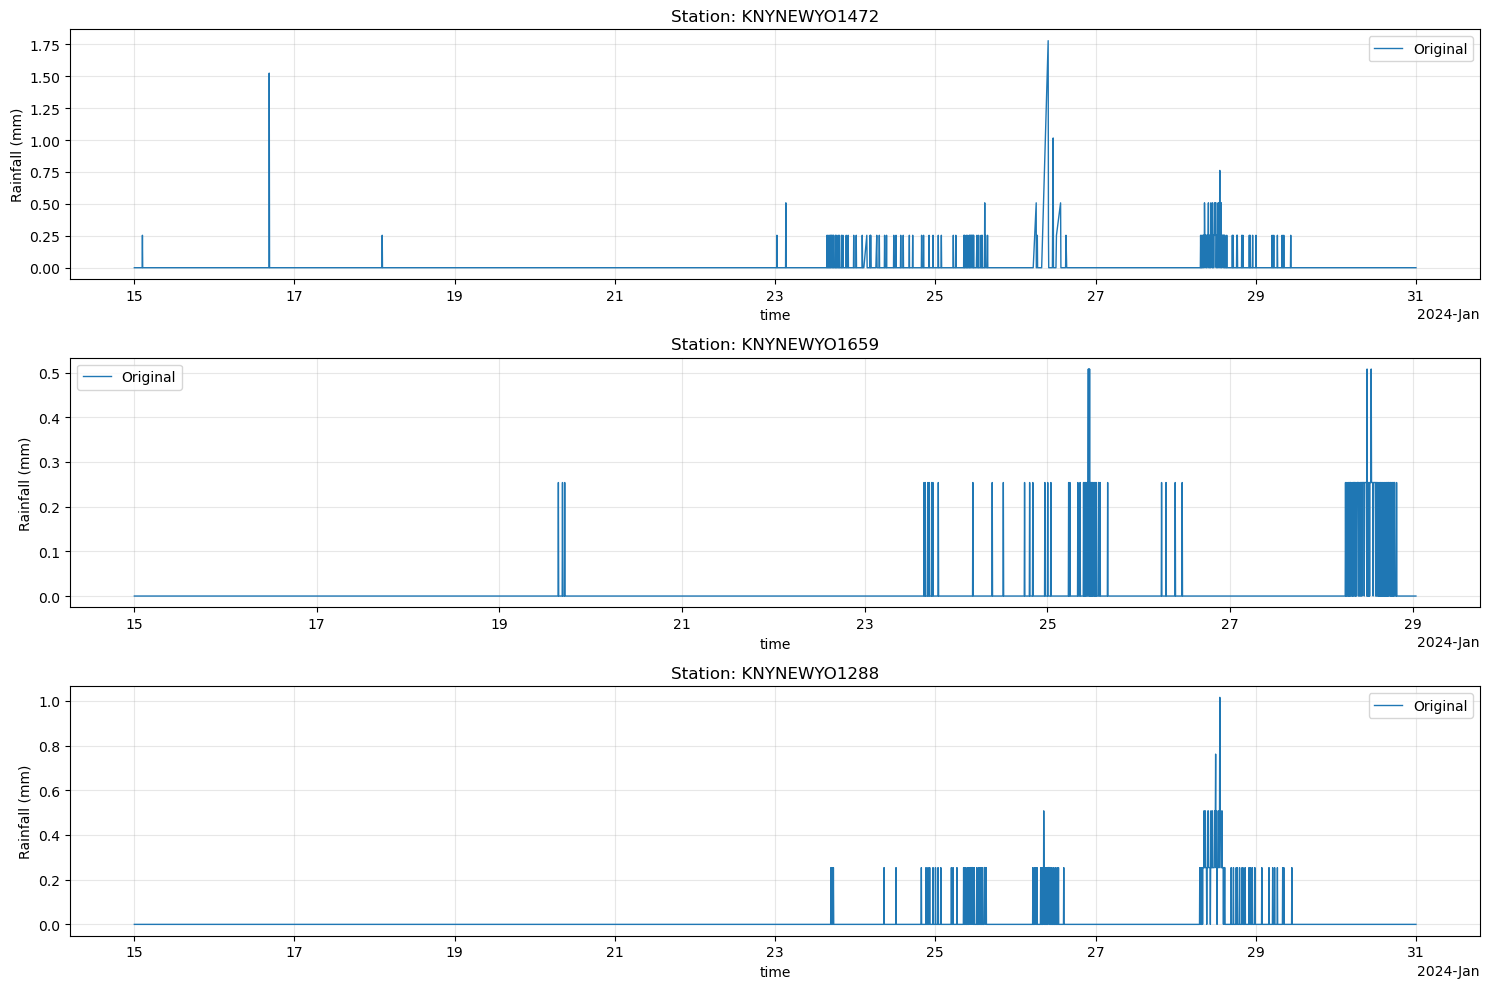


📊 Original data plotted for 3 stations


In [10]:
# Plot original data for a few stations
fig, axes = plt.subplots(3, 1, figsize=(15, 10))

# Select 3 stations to plot
stations_to_plot = list(pws_data.keys())[:3]

for idx, station_id in enumerate(stations_to_plot):
    ax = axes[idx]
    station_ds = pws_data[station_id]
    
    # Plot rainfall amount
    if 'rainfall_amount' in station_ds.data_vars:
        station_ds['rainfall_amount'].plot(ax=ax, label='Original', linewidth=1)
    elif 'rainfall_rate' in station_ds.data_vars:
        station_ds['rainfall_rate'].plot(ax=ax, label='Original', linewidth=1)
    
    ax.set_title(f'Station: {station_id}')
    ax.set_ylabel('Rainfall (mm)')
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

print("\n📊 Original data plotted for 3 stations")

## 7. Summary Statistics

Show basic stats before and after QC

In [11]:
print("RAINFALL SUMMARY (All Stations)")
print("="*70)
print(f"{'Station':<40s} {'Total (mm)':>12s} {'Max (mm)':>12s} {'Records':>10s}")
print("-"*70)

for station_id, station_ds in pws_data.items():
    if 'rainfall_amount' in station_ds.data_vars:
        total = float(station_ds['rainfall_amount'].sum().values)
        max_val = float(station_ds['rainfall_amount'].max().values)
        n_records = len(station_ds.time)
        print(f"{station_id:<40s} {total:12.2f} {max_val:12.2f} {n_records:10d}")

print("="*70)

RAINFALL SUMMARY (All Stations)
Station                                    Total (mm)     Max (mm)    Records
----------------------------------------------------------------------
KNYNEWYO1472                                    46.48         1.78       4402
KNYNEWYO1659                                    36.58         0.51       4606
KNYNEWYO1288                                    49.53         1.02       3743
KNYNEWYO1896                                    24.38         0.51       4606
KNYNEWYO1921                                    37.59         0.76       4605
KNYNEWYO1931                                    46.23         0.76       4606
KNYNEWYO1313                                    52.07         0.76       4604
KNYNEWYO1918                                     1.02         0.25       4604
KNYNEWYO1298                                    46.99         0.76       4606
KNYNEWYO1388                                    24.64         0.51       4599
KNYNEWYO1606                           

## 8. Close Dataset

In [12]:
# Close the netCDF file when done
ds_pws.close()
print("✓ Dataset closed")

✓ Dataset closed


## Notes on pypwsqc Usage

**Available QC Filters:**
- `so_filter`: Spatial outlier detection (compares stations)
- `so_filter_one_station`: Spatial outlier for single station
- `hi_filter`: High intensity filter (catches unrealistic rates)
- `fz_filter`: Freezing level filter (requires temperature data)

**Important:**
- pypwsqc may require specific data structure or metadata
- Check the documentation at: https://pypwsqc.readthedocs.io
- Some filters need lat/lon coordinates in the dataset
- Adjust thresholds based on your local climate

**Next Steps:**
1. Experiment with different threshold values
2. Compare QC results with known ground truth
3. Save QC-filtered data for analysis
4. Create visualizations showing flagged vs accepted data